In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

C:\Users\egorv\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
movies = pd.read_csv('movies.csv', sep = ',')
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy
9739,193585,Flint (2017),Drama
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation


In [3]:
ratings = pd.read_csv('ratings.csv', sep = ',')
ratings

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
100831,610,166534,4.0,1493848402
100832,610,168248,5.0,1493850091
100833,610,168250,5.0,1494273047
100834,610,168252,5.0,1493846352


In [4]:
user_ids = ratings['userId'].unique()
movie_ids = ratings['movieId'].unique()

user_map = {id: idx for idx, id in enumerate(user_ids)}
movie_map = {id: idx for idx, id in enumerate(movie_ids)}

ratings['user_id'] = ratings['userId'].map(user_map)
ratings['movie_id'] = ratings['movieId'].map(movie_map)

In [5]:
num_users = ratings['user_id'].nunique()
num_items = ratings['movie_id'].nunique()

print(num_users, num_items)

610 9724


In [6]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42
)

In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Input

# количество пользователей и фильмов
num_users = ratings['user_id'].nunique()
num_items = ratings['movie_id'].nunique()

# входные слои
user_input = Input(shape=(1,), name="user_input")
item_input = Input(shape=(1,), name="item_input")

In [8]:
from tensorflow.keras.layers import Embedding

embedding_size = 64

user_embedding = Embedding(
    input_dim=num_users,
    output_dim=embedding_size,
    name="user_embedding"
)(user_input)

item_embedding = Embedding(
    input_dim=num_items,
    output_dim=embedding_size,
    name="item_embedding"
)(item_input)

In [9]:
from tensorflow.keras.layers import Flatten

user_vector = Flatten()(user_embedding)
item_vector = Flatten()(item_embedding)

In [10]:
from tensorflow.keras.layers import Concatenate

combined = Concatenate()([user_vector, item_vector])

In [11]:
from tensorflow.keras.layers import Dense

dense1 = Dense(128, activation='relu')(combined)

In [12]:
dense2 = Dense(64, activation='relu')(dense1)

In [13]:
output = Dense(1)(dense2)

In [14]:
from tensorflow.keras.models import Model

model = Model(
    inputs=[user_input, item_input],
    outputs=output
)

In [15]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [16]:
train_user_ids = train['user_id'].values
train_movie_ids = train['movie_id'].values
train_ratings = train['rating'].values

test_user_ids = test['user_id'].values
test_movie_ids = test['movie_id'].values
test_ratings = test['rating'].values

In [17]:
history = model.fit(
    [train_user_ids, train_movie_ids],
    train_ratings,
    epochs=5,
    batch_size=256,
    validation_data=(
        [test_user_ids, test_movie_ids],
        test_ratings
    )
)

Epoch 1/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 1.7648 - mae: 0.9464 - val_loss: 0.7995 - val_mae: 0.6873
Epoch 2/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.7153 - mae: 0.6512 - val_loss: 0.7851 - val_mae: 0.6813
Epoch 3/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6717 - mae: 0.6275 - val_loss: 0.7711 - val_mae: 0.6736
Epoch 4/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.6287 - mae: 0.6034 - val_loss: 0.7673 - val_mae: 0.6771
Epoch 5/5
316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5791 - mae: 0.5770 - val_loss: 0.7890 - val_mae: 0.6836


In [18]:
model.evaluate(
    [test_user_ids, test_movie_ids],
    test_ratings
)

631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7890 - mae: 0.6836


[0.7890177369117737, 0.6836231350898743]

In [19]:
preds = model.predict([test_user_ids, test_movie_ids]).flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(test_ratings, preds))
mae = mean_absolute_error(test_ratings, preds)

print("RMSE:", rmse)
print("MAE:", mae)

631/631 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step    
RMSE: 0.8882669594300013
MAE: 0.6836236178674002


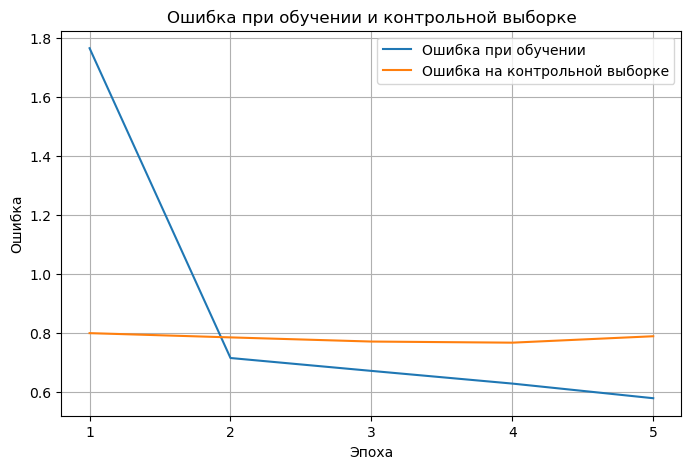

In [28]:
import matplotlib.pyplot as plt

epochs = range(1, 6)  # 5 эпох

plt.figure(figsize=(8, 5))

plt.plot(epochs, history.history['loss'], label='Ошибка при обучении')
plt.plot(epochs, history.history['val_loss'], label='Ошибка на контрольной выборке')

plt.title("Ошибка при обучении и контрольной выборке")
plt.xlabel("Эпоха")
plt.ylabel("Ошибка")
plt.xticks(epochs)

plt.legend()
plt.grid()
plt.show()

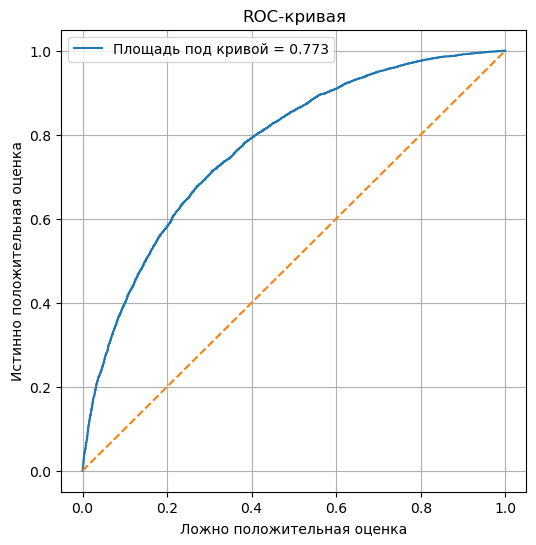

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# бинаризация оценок
y_true = (test_ratings >= 4).astype(int)

# предсказания модели
y_scores = preds

# ROC-кривая
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# AUC
roc_auc = auc(fpr, tpr)

# график
plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f'Площадь под кривой = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('Ложно положительная оценка')
plt.ylabel('Истинно положительная оценка')
plt.title('ROC-кривая')

plt.legend()
plt.grid()

plt.show()

In [66]:
model.save("models/recommender_model.keras")

In [ ]:
import pickle

with open("movie_map.pkl", "wb") as f:
    pickle.dump(movie_map, f)